In [ ]:
# Устанавливаем библиотеку Ultralytics (в ней живет YOLOv8)
!pip install ultralytics

# Импортируем нужные модули для работы
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

print("Установка завершена! Готовы к работе с YOLOv8.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Установка завершена! Готовы к работе с YOLOv8.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="KTRgki9dxdmFUDNVdABa")
project = rf.workspace("modeltrainingground").project("food_detection-djoh0")
version = project.version(7)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import yaml
import os
from ultralytics import YOLO

# 1. АВТО-ИСПРАВЛЕНИЕ ПУТЕЙ (чтобы YOLO точно нашла картинки)
yaml_path = f"{dataset.location}/data.yaml"
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

# Умный поиск папки валидации
if os.path.exists(f"{dataset.location}/val/images"):
    val_path = f"{dataset.location}/val/images"
elif os.path.exists(f"{dataset.location}/valid/images"):
    val_path = f"{dataset.location}/valid/images"
else:
    val_path = f"{dataset.location}/train/images" # Хак, если валидации нет

# Записываем абсолютные пути
data_yaml['train'] = f"{dataset.location}/train/images"
data_yaml['val'] = val_path
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print("Файл data.yaml настроен идеально!")

# 2. ЗАПУСК ОБУЧЕНИЯ (Transfer Learning)
print("Загружаем веса и стартуем тренировку...")
model = YOLO('yolov8n.pt')

results = model.train(
    data=yaml_path,                       # Наш исправленный паспорт
    epochs=15,                            # 15 проходов по датасету
    imgsz=640,                            # Размер картинки
    batch=16,                             # Размер батча
    project='NutriCheck_Project',         # Наша папка проекта
    name='First_Checkpoint_Success'       # Имя финального прогона
)

Файл data.yaml настроен идеально!
Загружаем веса и стартуем тренировку...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Food_Detection-7/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=First_Checkpoint_Success, nbs=64, 

Тестируем модель на картинке: cooked_fish_009_jpg.rf.97b00c7cb4710d5977734b0bace26115.jpg

image 1/1 /content/Food_Detection-7/valid/images/cooked_fish_009_jpg.rf.97b00c7cb4710d5977734b0bace26115.jpg: 640x448 1 cooked_fish, 1 cooked_pork, 40.6ms
Speed: 2.3ms preprocess, 40.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 448)


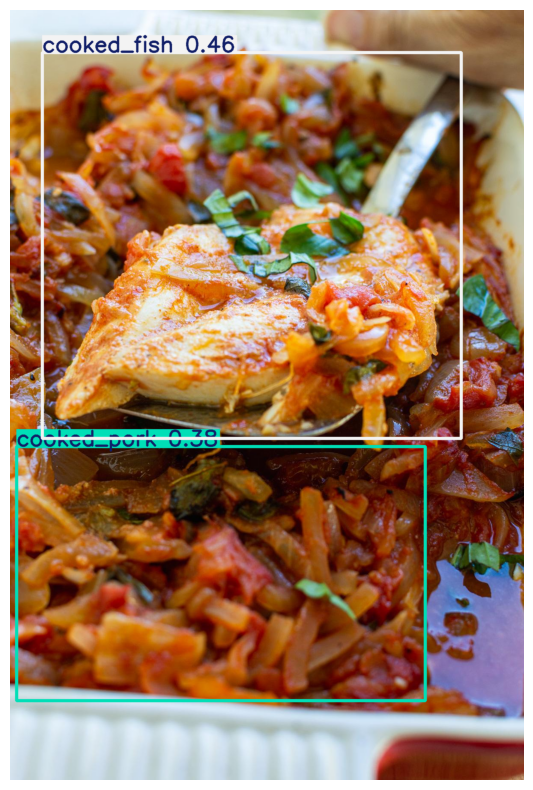

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Загружаем НАШУ обученную модель (самые лучшие веса)
model_path = '/content/runs/detect/NutriCheck_Project/First_Checkpoint_Success/weights/best.pt'
my_model = YOLO(model_path)

# 2. Берем случайную картинку из папки валидации, чтобы проверить работу
val_images_path = f"{dataset.location}/valid/images"
random_image_name = random.choice(os.listdir(val_images_path))
image_path = os.path.join(val_images_path, random_image_name)

print(f"Тестируем модель на картинке: {random_image_name}")

# 3. Делаем предсказание (Inference)
results = my_model.predict(source=image_path, conf=0.25) # conf=0.25 значит "показывай рамку, если уверен на 25%+"

# 4. Рисуем и выводим результат на экран
res_plotted = results[0].plot() # YOLO сама нарисует рамки и подпишет классы
res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB) # Переводим цвета для правильного отображения

plt.figure(figsize=(10, 10))
plt.imshow(res_rgb)
plt.axis('off')
plt.show()

Графики обучения (Loss и mAP):


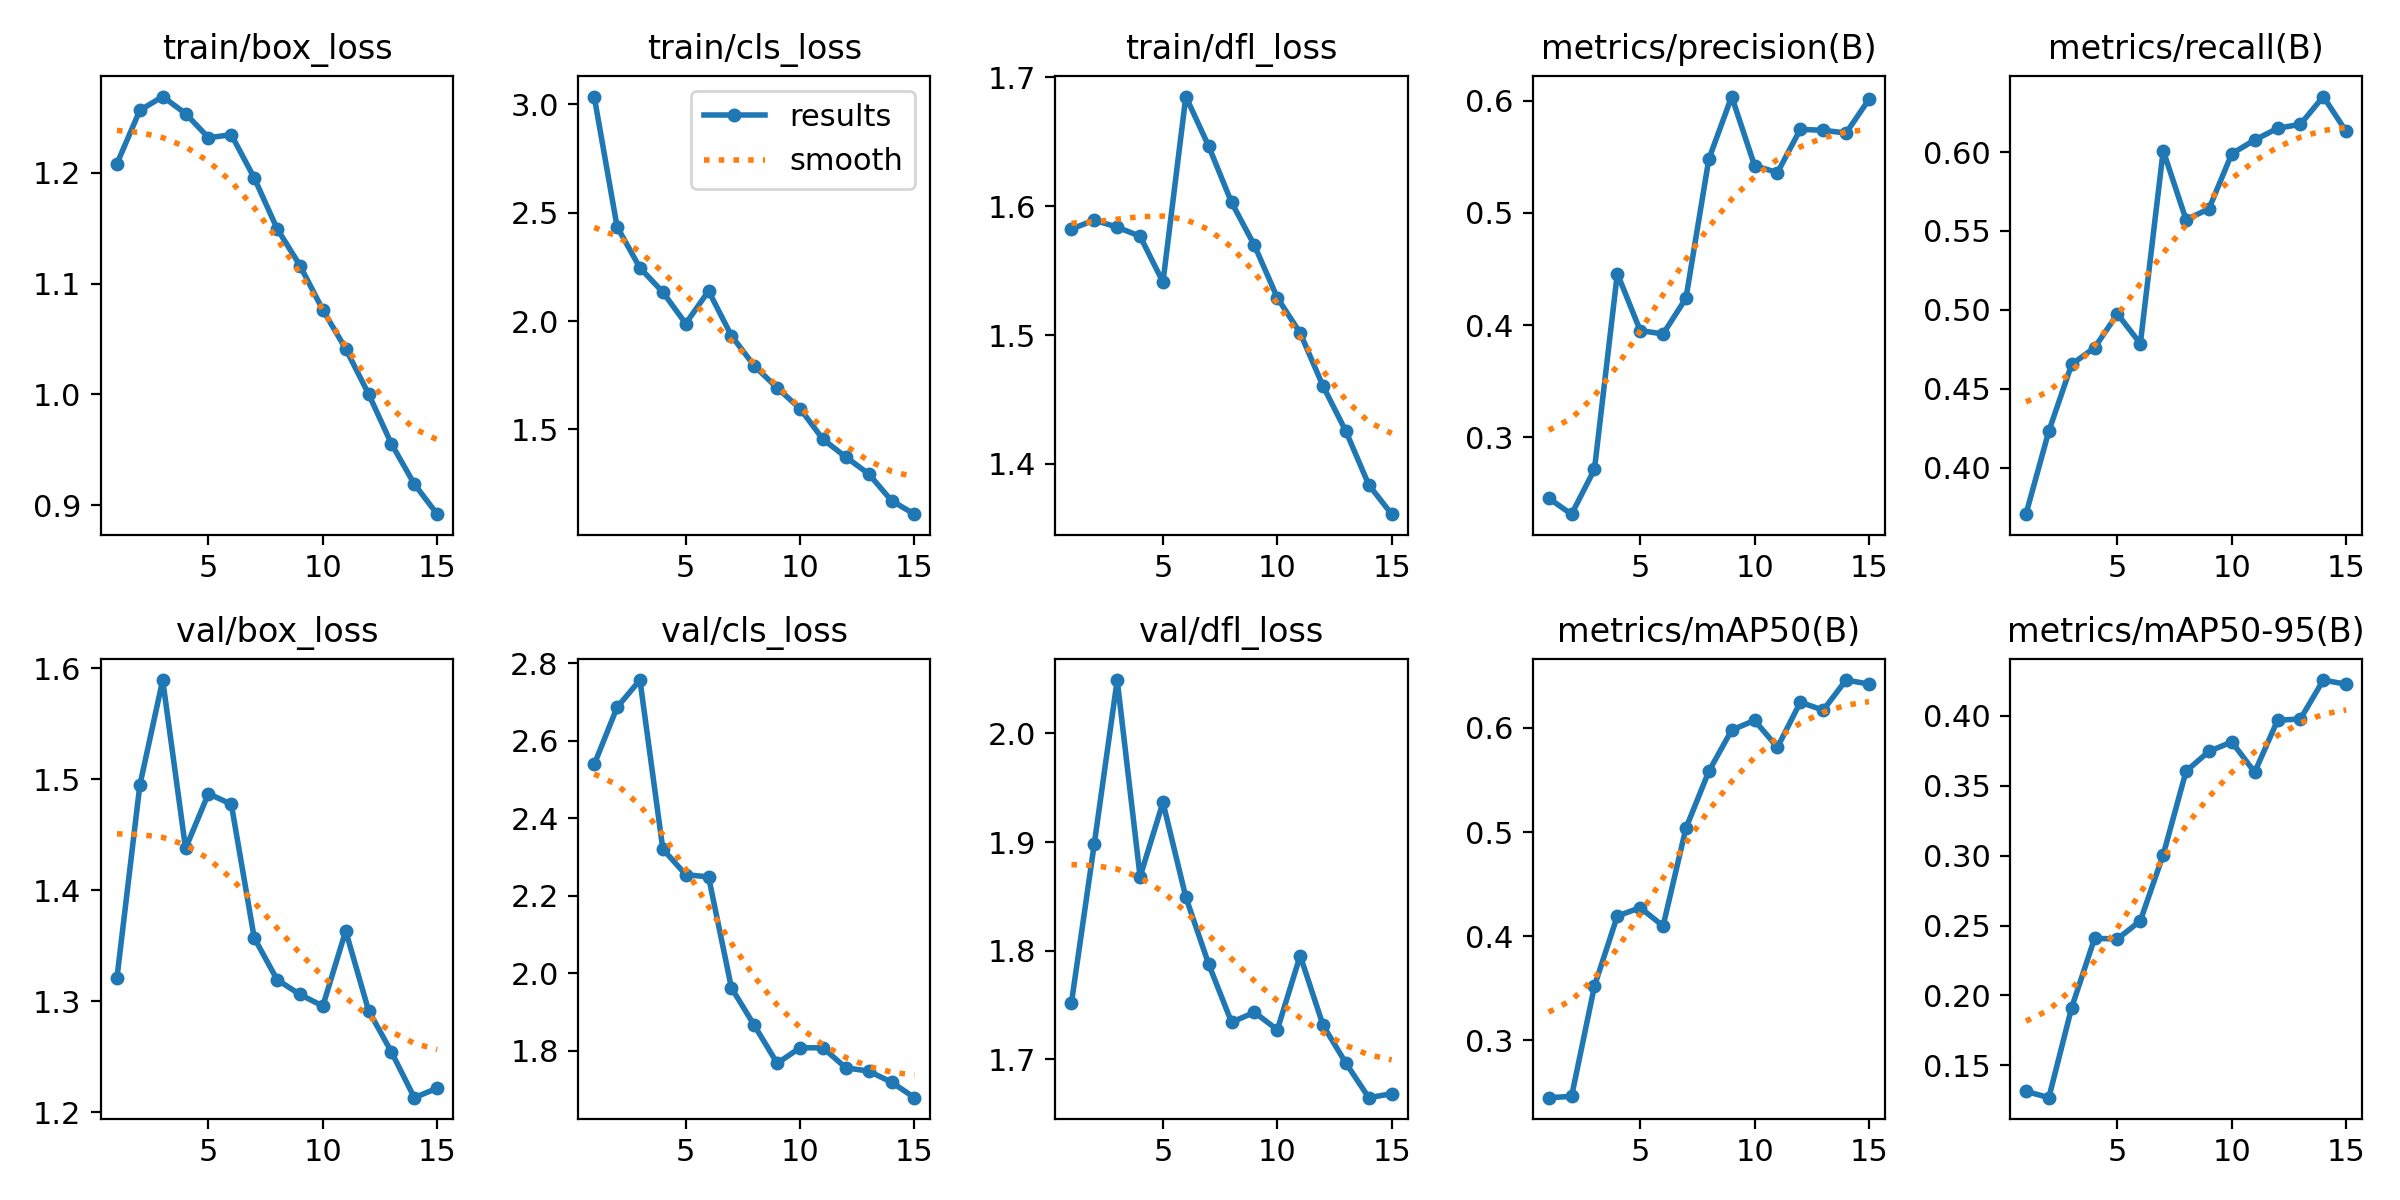

In [ ]:
from IPython.display import Image, display
import os

# Путь к папке с нашими результатами
results_dir = '/content/runs/detect/NutriCheck_Project/First_Checkpoint_Success/'

print("Графики обучения (Loss и mAP):")
display(Image(filename=os.path.join(results_dir, 'results.png'), width=800))

Коллаж предсказаний нашей модели на валидационной выборке:


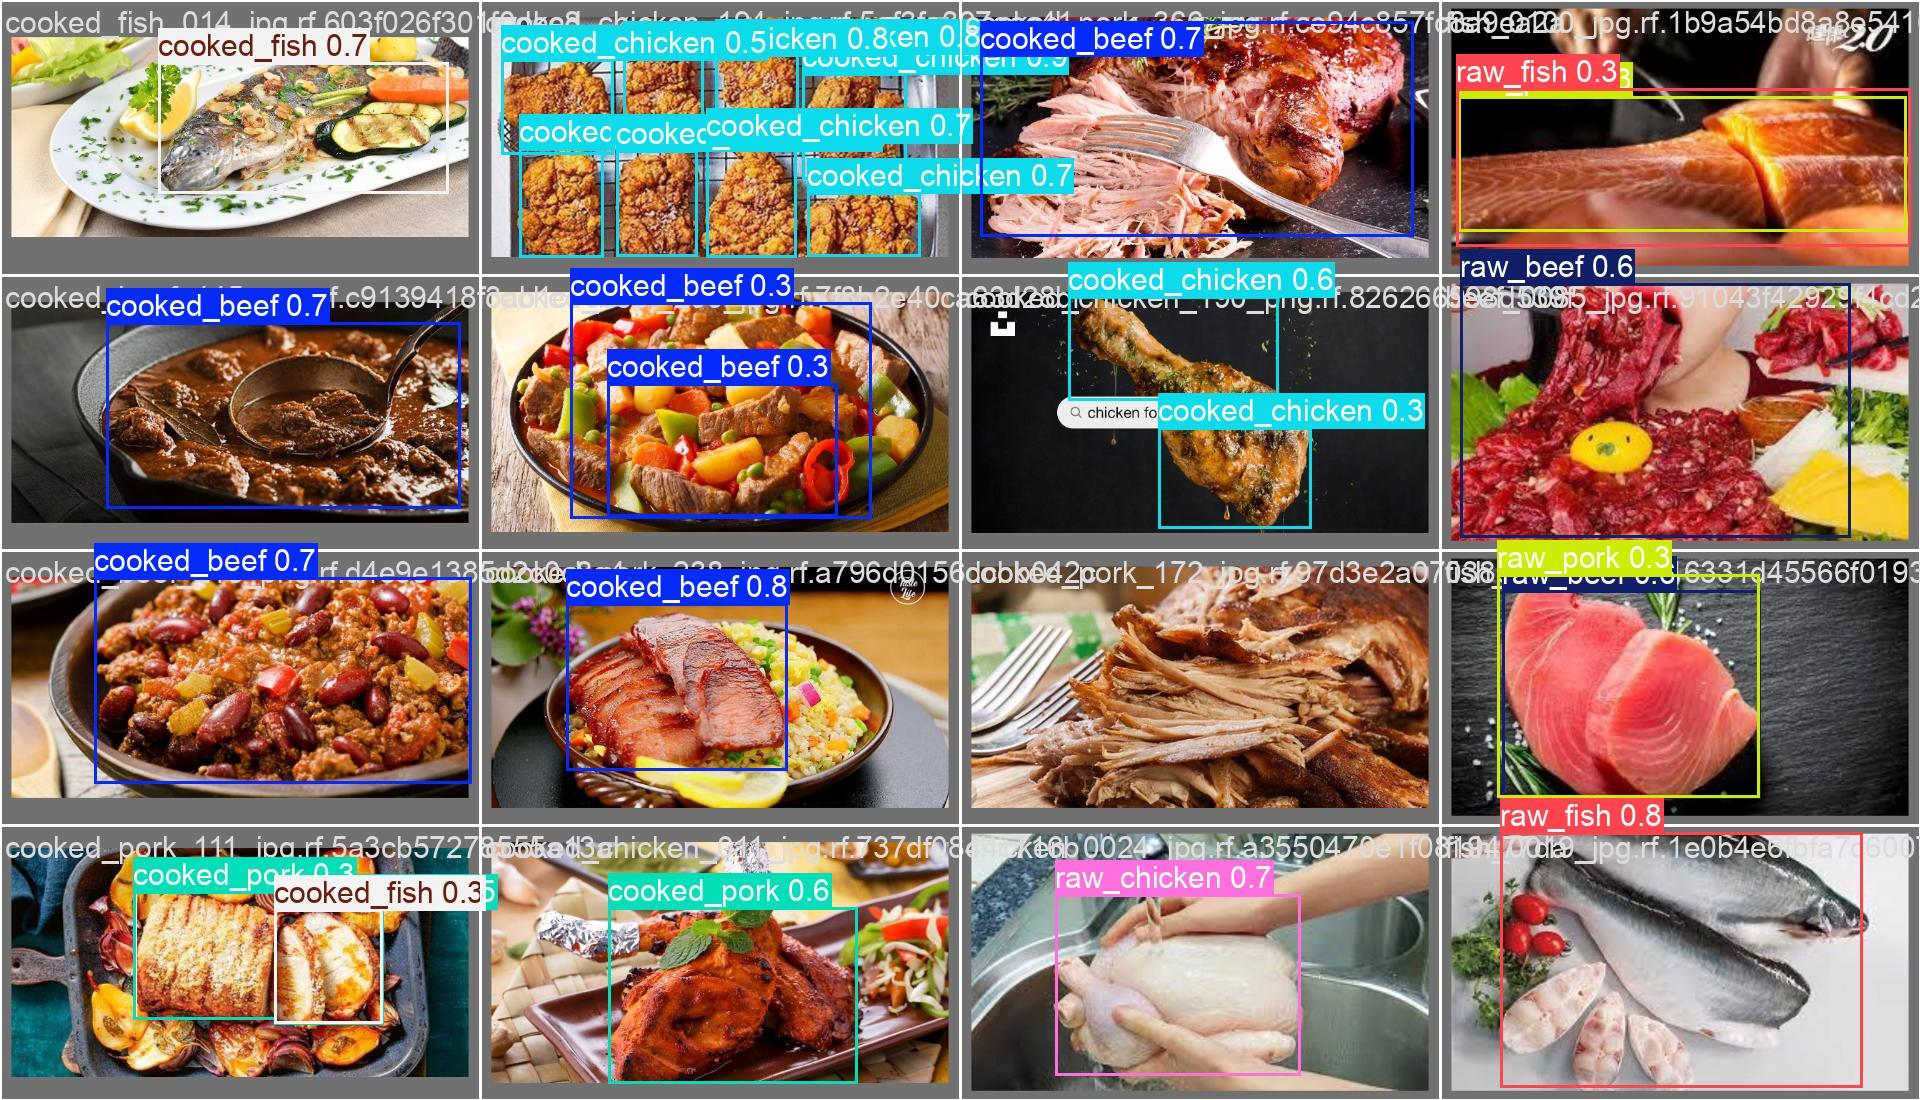

In [ ]:
import os
from IPython.display import Image, display

# Путь к папке, где YOLO сохранила картинки с предсказаниями на валидации
# Она создает их автоматически в конце обучения!
validation_predictions_path = '/content/runs/detect/NutriCheck_Project/First_Checkpoint_Success/val_batch0_pred.jpg'

print("Коллаж предсказаний нашей модели на валидационной выборке:")
if os.path.exists(validation_predictions_path):
    display(Image(filename=validation_predictions_path, width=1000))
else:
    print("Коллаж не найден. Проверь путь к папке результатов обучения.")

Матрица ошибок (Confusion Matrix):


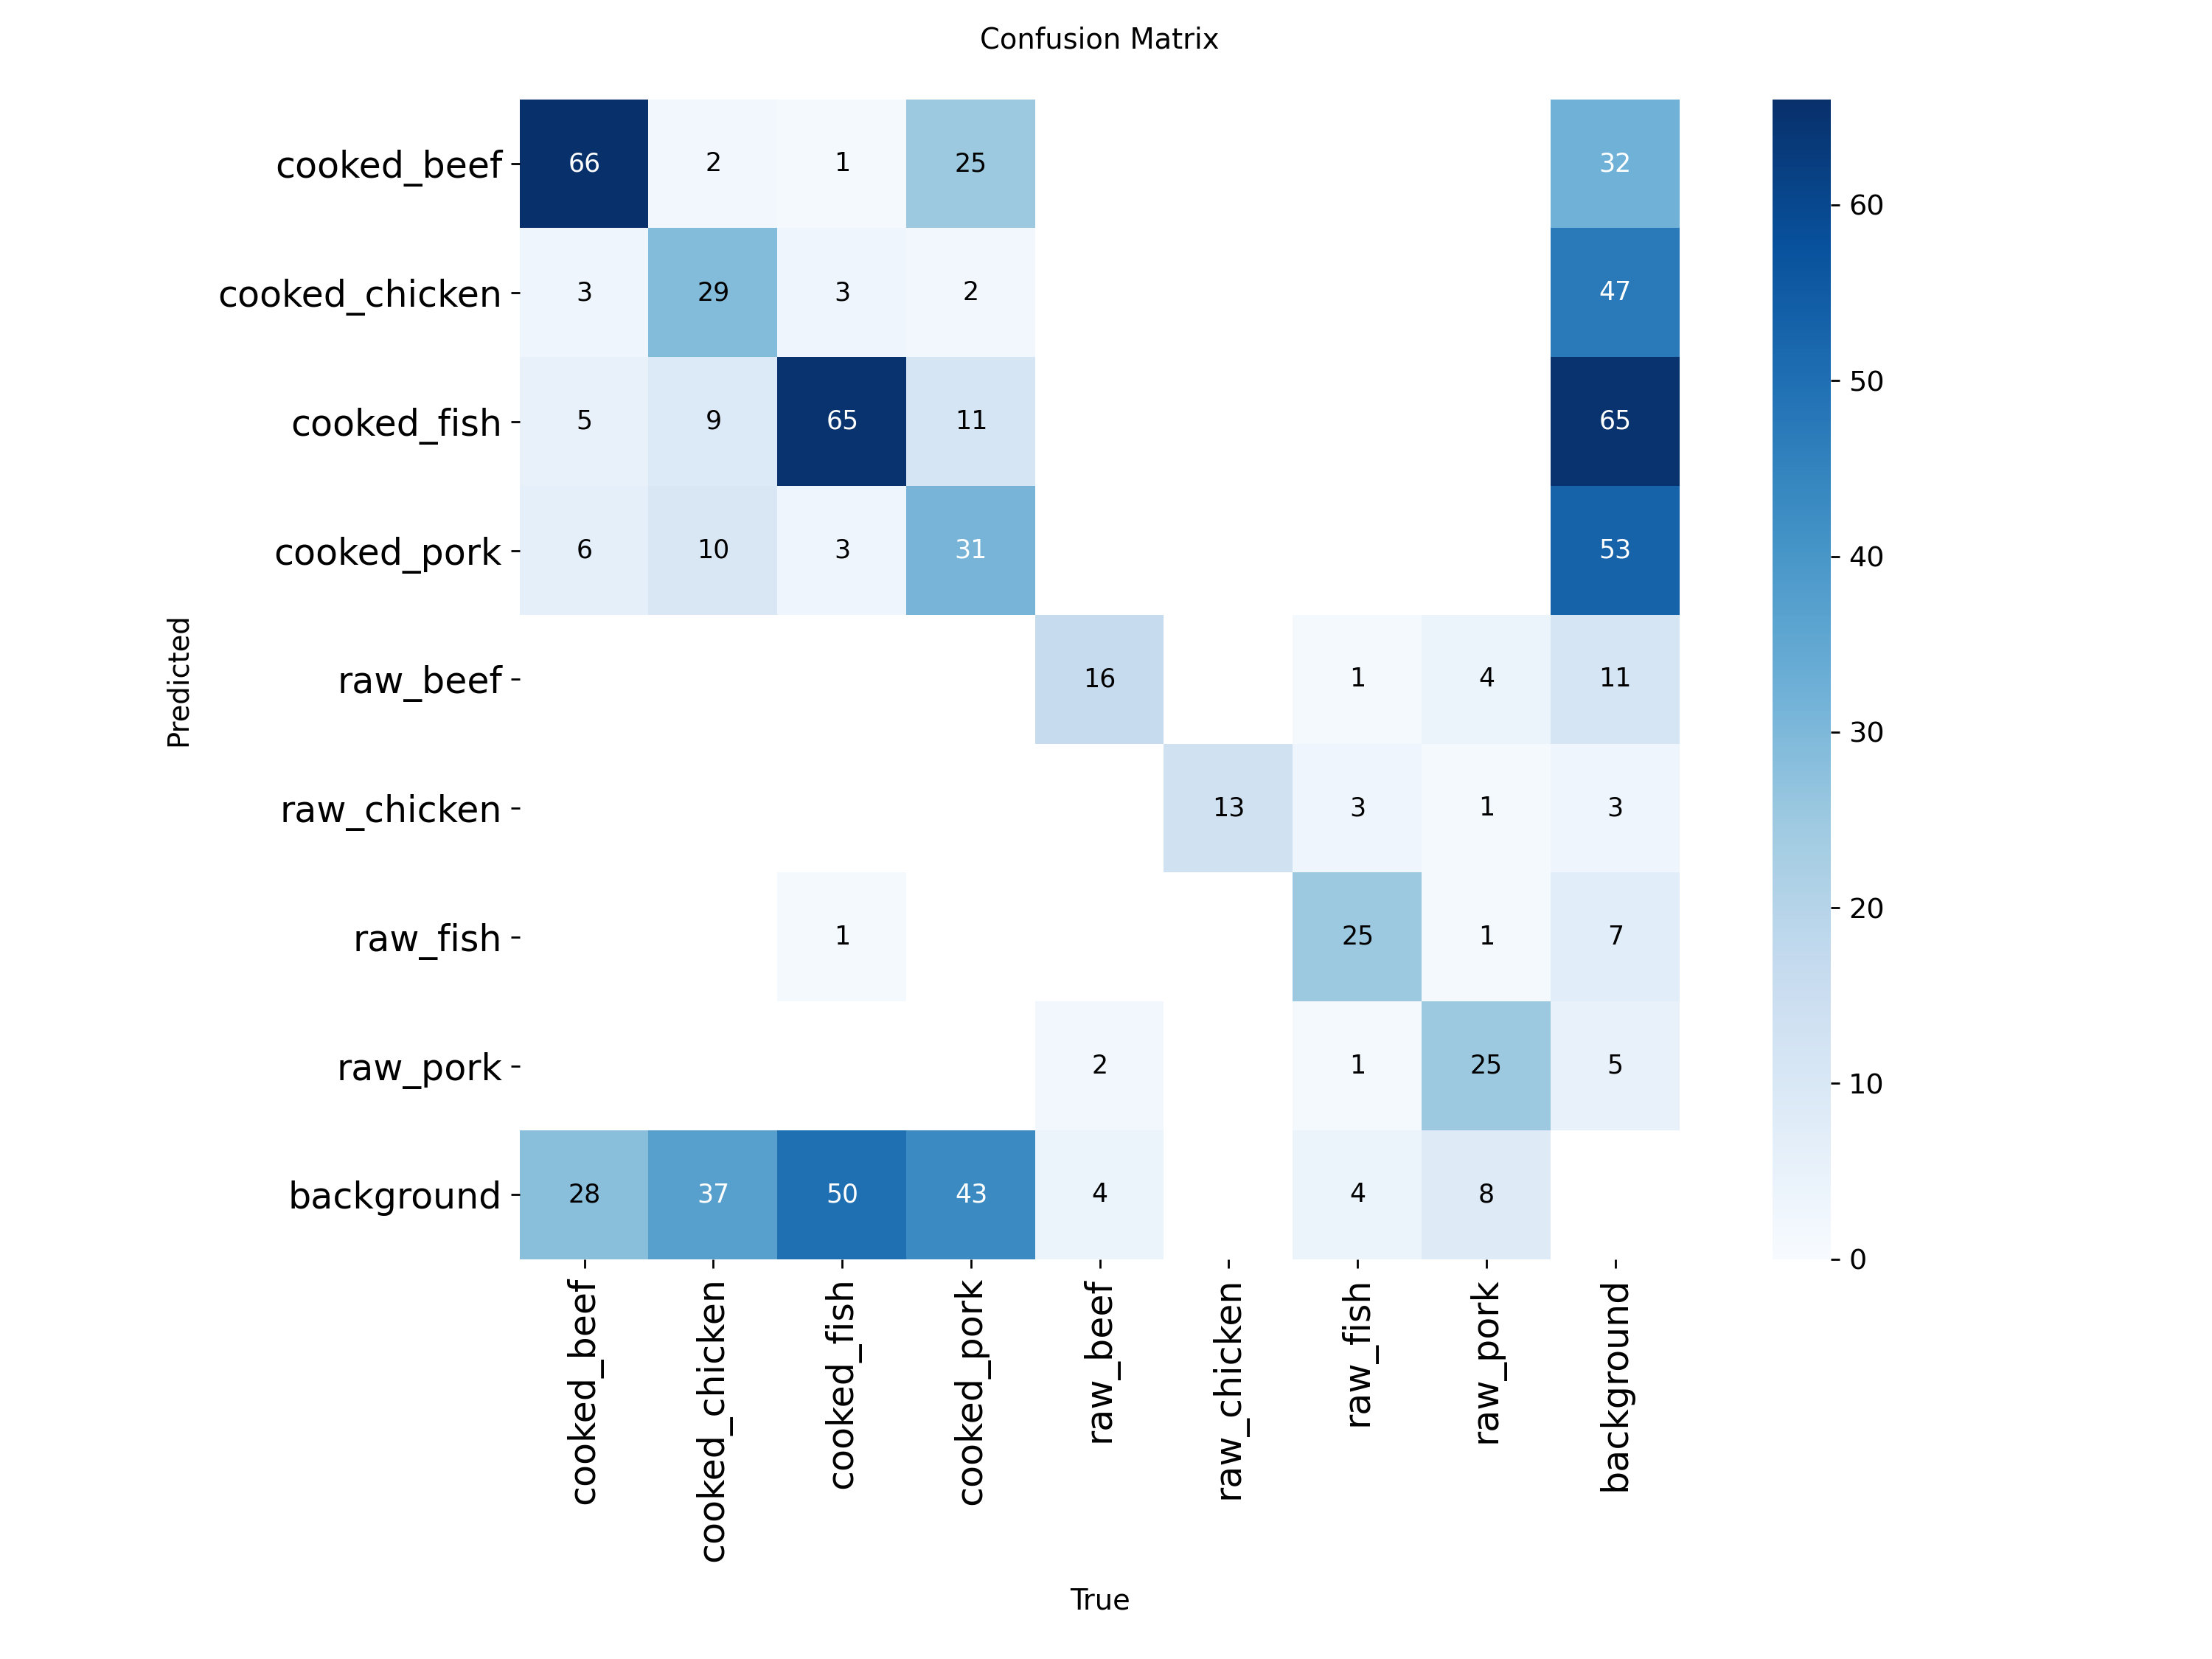

In [ ]:
from IPython.display import Image, display
import os

results_dir = '/content/runs/detect/NutriCheck_Project/First_Checkpoint_Success/'
conf_matrix_path = os.path.join(results_dir, 'confusion_matrix.png')

print("Матрица ошибок (Confusion Matrix):")
if os.path.exists(conf_matrix_path):
    display(Image(filename=conf_matrix_path, width=800))
else:
    print("Матрица ошибок не найдена.")